# Propene Autoencoder Latent PCA

This notebook trains a compact `AutoencoderExcitedMACE` model on the full propene dataset, extracts the 16D invariant latent vector from each geometry, and visualizes those latent vectors with PCA.

Generated plots and arrays are written to `nicer_tutorials/_outputs/04_pca/`.


## 1. Setup And Imports

In [ ]:
import os
import time
from pathlib import Path

TUTORIAL_ROOT = Path(os.getcwd())
DATA_DIR = TUTORIAL_ROOT / "data"
OUTPUT_DIR = TUTORIAL_ROOT / "_outputs" / "04_pca"
GRAPH_DIR = OUTPUT_DIR / "graphs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

XYZ_FILE = DATA_DIR / "xyz" / "A02_propene_grid_static.xyz"

# Keep matplotlib cache files inside the ignored output folder.
MPLCONFIGDIR = OUTPUT_DIR / "matplotlib_cache"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import numpy as np
import ase.io
import torch
from e3nn import o3
import matplotlib.pyplot as plt

from mace import data, modules, tools
from mace.tools import torch_geometric

DEVICE = torch.device("cpu")

print("TUTORIAL_ROOT:", TUTORIAL_ROOT)
print("XYZ_FILE:", XYZ_FILE)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("DEVICE:", DEVICE)


## 2. Prepare And Train Minimal Example Model


In [26]:
# Use every geometry in the propene extended XYZ file.
atoms_list = ase.io.read(str(XYZ_FILE), index=":")
DATASET_SIZE = len(atoms_list)

configs = data.config_from_atoms_list(
    atoms_list,
    energy_key="REF_energy",
    forces_key="REF_forces",
    config_type_weights={"Default": 1.0},
)

R_MAX = 5.0
BATCH_SIZE = 16
VALID_FRACTION = 0.2
SEED = 123
LATENT_DIM = 16
N_ENERGIES = 3
MAX_EPOCHS = 50

train_configs, valid_configs = data.random_train_valid_split(
    configs,
    valid_fraction=VALID_FRACTION,
    seed=SEED,
    work_dir=str(OUTPUT_DIR),
)

z_table = tools.get_atomic_number_table_from_zs(
    z for config in (train_configs + valid_configs) for z in config.atomic_numbers
)

atomic_energies_dict = data.compute_average_E0s(train_configs, z_table)
atomic_energies = np.array([atomic_energies_dict[z] for z in z_table.zs], dtype=np.float64)

train_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in train_configs
]
valid_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in valid_configs
]
all_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in configs
]

train_loader = torch_geometric.dataloader.DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
valid_loader = torch_geometric.dataloader.DataLoader(
    valid_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
all_loader = torch_geometric.dataloader.DataLoader(
    all_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

avg_num_neighbors = modules.compute_avg_num_neighbors(train_loader)

model = modules.AutoencoderExcitedMACE(
    r_max=R_MAX,
    num_bessel=4,
    num_polynomial_cutoff=3,
    num_permutational_invariant=LATENT_DIM,
    n_energies=N_ENERGIES,
    max_ell=2,
    interaction_cls=modules.interaction_classes["RealAgnosticResidualInteractionBlock"],
    interaction_cls_first=modules.interaction_classes["RealAgnosticResidualInteractionBlock"],
    num_interactions=1,
    num_elements=len(z_table),
    hidden_irreps=o3.Irreps("4x0e + 4x1o"),
    MLP_irreps=o3.Irreps("16x0e"),
    atomic_energies=atomic_energies,
    avg_num_neighbors=float(avg_num_neighbors),
    atomic_numbers=[int(z) for z in z_table.zs],
    correlation=1,
    gate=modules.gate_dict["silu"],
    radial_MLP=[32, 32],
    compute_nacs=False,
    compute_socs=False,
    nac_num=0,
    soc_num=0,
).to(DEVICE)

loss_fn = modules.InvariantsWeightedEnergyForcesNacsDipoleLoss(
    energy_weight=1.0,
    forces_weight=5.0,
    dipoles_weight=0.0,
    nacs_weight=0.0,
    socs_weight=0.0,
)

optimizer = torch.optim.Adam(model.parameters(), lr=1.0e-3)
history = []

def add_autoencoder_targets(active_model, batch, output):
    centred_reference_energy = (
        batch["energy"] - output["e0s"] - output["pair_energy"]
    ).unsqueeze(-1)

    output["encoded_energy"] = active_model.perm_encoder(centred_reference_energy)
    output["decoded_energy"] = (
        active_model.perm_decoder(output["encoded_energy"])
        + output["e0s"]
        + output["pair_energy"]
    )
    return output

def compute_batch_loss(batch, training):
    batch = batch.to(DEVICE)
    output = model(
        batch.to_dict(),
        training=training,
        compute_force=True,
        compute_virials=False,
        compute_stress=False,
    )
    output = add_autoencoder_targets(model, batch, output)
    loss = loss_fn(ref=batch, pred=output)
    return loss, output

for epoch in range(MAX_EPOCHS):
    epoch_start = time.time()
    model.train()
    train_losses = []

    for batch in train_loader:
        optimizer.zero_grad(set_to_none=True)
        loss, _ = compute_batch_loss(batch, training=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    model.eval()
    valid_losses = []

    for batch in valid_loader:
        loss, _ = compute_batch_loss(batch, training=False)
        valid_losses.append(float(loss.detach().cpu()))

    history.append(
        {
            "epoch": epoch + 1,
            "train_loss": float(np.mean(train_losses)),
            "valid_loss": float(np.mean(valid_losses)),
            "seconds": round(time.time() - epoch_start, 2),
        }
    )
    row = history[-1]
    print(f"Epoch {row['epoch']:03d} | train_loss={row['train_loss']:.6f} | valid_loss={row['valid_loss']:.6f}")


/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript typ

Epoch 001 | train_loss=78.737454 | valid_loss=26.090779
Epoch 002 | train_loss=23.112090 | valid_loss=20.818365
Epoch 003 | train_loss=20.633978 | valid_loss=19.883492
Epoch 004 | train_loss=20.493097 | valid_loss=19.111405
Epoch 005 | train_loss=18.471392 | valid_loss=18.396445
Epoch 006 | train_loss=17.792540 | valid_loss=18.746909
Epoch 007 | train_loss=17.211671 | valid_loss=17.265841
Epoch 008 | train_loss=16.497062 | valid_loss=16.590971
Epoch 009 | train_loss=16.218859 | valid_loss=15.804789
Epoch 010 | train_loss=15.532689 | valid_loss=15.279939
Epoch 011 | train_loss=15.401301 | valid_loss=15.057644
Epoch 012 | train_loss=15.446742 | valid_loss=14.900007
Epoch 013 | train_loss=14.684666 | valid_loss=14.314145
Epoch 014 | train_loss=15.257434 | valid_loss=15.774867
Epoch 015 | train_loss=14.580520 | valid_loss=14.231386
Epoch 016 | train_loss=14.537554 | valid_loss=14.290307
Epoch 017 | train_loss=14.250905 | valid_loss=14.193581
Epoch 018 | train_loss=14.599261 | valid_loss=15

## 3. Extract 16D Latent Space

Now run the full model (trained) on all the data again, saving the latent features from`output["invariant_vals"]`. This is the low dimensional latent space that the model learns through the autoencoder. 

Here we are just interested to inspect how the latent space "looks like". 


In [27]:
model.eval()
latent_batches = []
energy_batches = []

for batch in all_loader:
    batch = batch.to(DEVICE)
    output = model(
        batch.to_dict(),
        training=False,
        compute_force=False,
        compute_virials=False,
        compute_stress=False,
    )
    latent_batches.append(output["invariant_vals"].detach().cpu().numpy())
    energy_batches.append(batch["energy"].detach().cpu().numpy())

latent_vectors = np.concatenate(latent_batches, axis=0)
reference_energies = np.concatenate(energy_batches, axis=0)
# Select the ground state for colour plotting
reference_state_energy = reference_energies[:, 0]

print("latent_vectors shape:", latent_vectors.shape)
print("reference_energies shape:", reference_energies.shape)
print("reference_state_energy shape:", reference_state_energy.shape)


latent_vectors shape: (3731, 16)
reference_energies shape: (3731, 3)
reference_state_energy shape: (3731,)


## 4. PCA Projection Of Latent Space

The PCA is computed with NumPy SVD to avoid adding a scikit-learn dependency. The input is centered before decomposition.
Can visualise the important directions within the 16D picture. 

TBH using latent space to sample rather than geometric descriptors seems more promising because this manifold might not be smooth, but geometric descriptors should be a continuos normal distribution (?). Then sampling evenly or coming up with a good strategy with geometric desciptors seems quite hard to outperform just randomly selecting (which should be the baseline)



In [28]:
latent_mean = latent_vectors.mean(axis=0, keepdims=True)
latent_centered = latent_vectors - latent_mean

# SVD: latent_centered = U S Vt. The PCA coordinates are U*S.
U, S, Vt = np.linalg.svd(latent_centered, full_matrices=False)
pca_2d = U[:, :2] * S[:2]

variance = S**2 / (latent_centered.shape[0] - 1)
explained_variance_ratio = variance / variance.sum()

print("pca_2d shape:", pca_2d.shape)
print("Explained variance PC1:", float(explained_variance_ratio[0]))
print("Explained variance PC2:", float(explained_variance_ratio[1]))


pca_2d shape: (3731, 2)
Explained variance PC1: 0.8150454163551331
Explained variance PC2: 0.13570049405097961


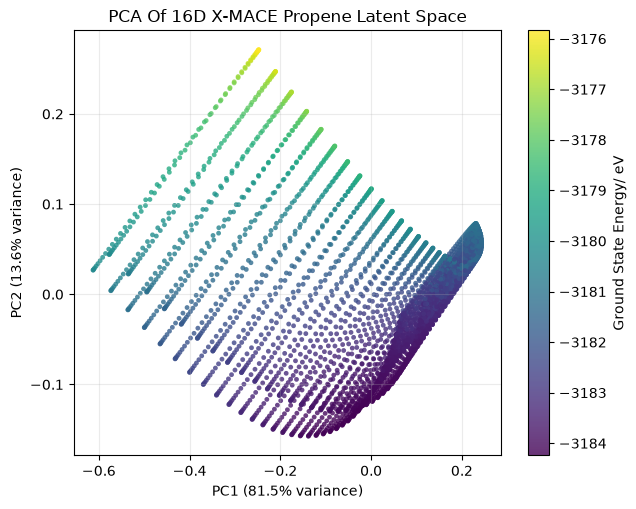

In [29]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))
scatter = ax.scatter(
    pca_2d[:, 0],
    pca_2d[:, 1],
    c=reference_state_energy,
    s=12,
    cmap="viridis",
    alpha=0.8,
    linewidths=0,
)
ax.set_xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)")
ax.set_title("PCA Of 16D X-MACE Propene Latent Space")
ax.grid(True, alpha=0.25)
colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label(f"Ground State Energy/ eV")
fig.tight_layout()

PCA_PLOT_PATH = GRAPH_DIR / f"latent_pca_reference_ground_state.png"
fig.savefig(PCA_PLOT_PATH, dpi=150)
plt.show()


## 5. UMAP Projection Of Latent Space

UMAP is another nonlinear dimensionality-reduction method. PCA tries to preserve global linear variance, while UMAP often makes local clusters and curved manifolds easier to see.


```bash
mamba install -c conda-forge umap-learn
```
Might have issues with numpy, might need to downgrade to <2.4
```


In [30]:
NUMBA_CACHE_DIR = OUTPUT_DIR / "numba_cache"
NUMBA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("NUMBA_CACHE_DIR", str(NUMBA_CACHE_DIR))

import umap
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.05
UMAP_RANDOM_STATE = 123

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric="euclidean",
    random_state=UMAP_RANDOM_STATE,
)
umap_2d = umap_model.fit_transform(latent_vectors)
print("umap_2d shape:", umap_2d.shape)


/opt/miniconda3/envs/mlip/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


umap_2d shape: (3731, 2)


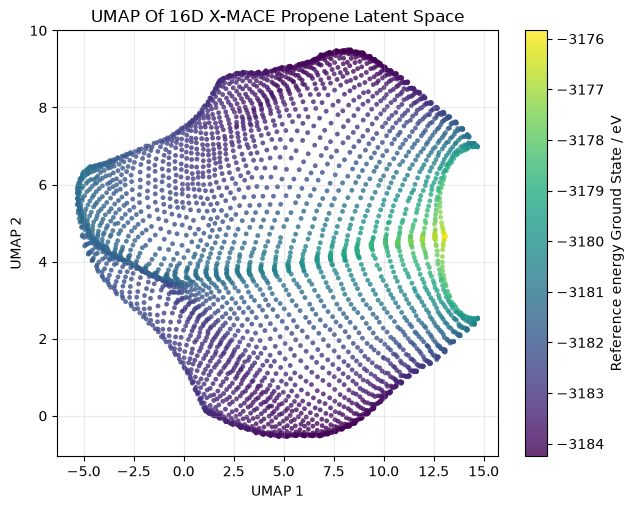

In [33]:
if umap_2d is not None:
    fig, ax = plt.subplots(figsize=(6.5, 5.2))
    scatter = ax.scatter(
        umap_2d[:, 0],
        umap_2d[:, 1],
        c=reference_state_energy,
        s=12,
        cmap="viridis",
        alpha=0.8,
        linewidths=0,
    )
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title("UMAP Of 16D X-MACE Propene Latent Space")
    ax.grid(True, alpha=0.25)
    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label(f"Reference energy Ground State / eV")
    fig.tight_layout()

    UMAP_PLOT_PATH = GRAPH_DIR / f"latent_umap_reference_ground_state.png"
    fig.savefig(UMAP_PLOT_PATH, dpi=150)
    plt.show()
